### Why Regularization is needed?
Overfitting happens when:
- Model is too complex
- Too many features
- Multicollinearity exists
- Small data

In regression:
Large weights -> model becomes unstable.

Example:
```
Price = 0.05*Area + 200*Bedrooms - 500*Age
```

Huge coefficients = sensitive model.

Regularization solves this.

### Core Idea of Regularization
Add penalty to cost function:
```
New Cost = MSE + Penalty
```

Penalty discourages large weights.

### Ridge Regression (L2 Regularization)
#### Cost Function
$
J(w) = MSE + \lambda \sum w_i^2
$

Where:   
- $\lambda$ (lambda) = regularization strength
- Penalizes squared weights

#### Effect
- Shrinks weights
- Reduces variance
- Handles multicollinearity

**But**: Does **NOT** make weights exactly zero


#### Python Example

OLS MSE:  3.4417355191779295
Ridge MSE:  3.1685000746533154

OLS Coefficients:  [ 7.77855994 -2.94911934 -2.80824799]
Ridge Coefficients:  [ 2.82036949  1.88035688 -2.64843501]
Best Alpha: 0.049770235643321115
Best Coefficients: [ 7.51507965 -2.6862408  -2.80694768]


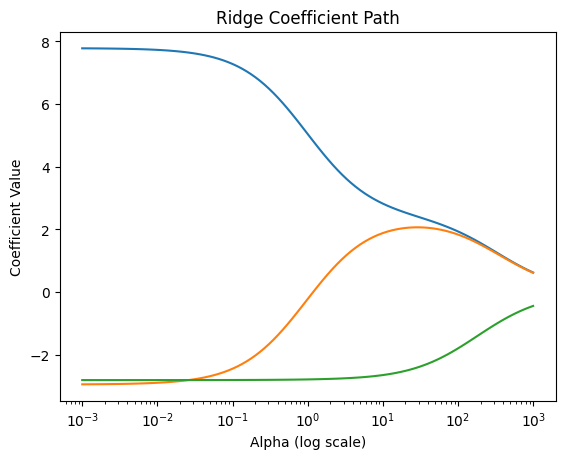

In [1]:
'''
Create Dataset with Multicollinearity
'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV

np.random.seed(42)

n = 200

# Independent feature
X1 = np.random.randn(n)

# Highly correlated feature
X2 = X1 * 0.9 + np.random.randn(n) * 0.1

# Independent feature
X3 = np.random.randn(n)

# Target (true relationship)
y = 5*X1 - 3*X3 + np.random.randn(n) * 2

X = np.column_stack([X1, X2, X3])

'''
Here:
- X1 and X2 are strongly correlated
- OLS will struggle with stable coefficients
'''

'''
Train-Test Split + Standardization
'''


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

'''
Compare OLS (Ordinary Least Square) vs Ridge
'''

# OLS
ols = LinearRegression()
ols.fit(X_train, y_train)

# Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

# Prediction
ols_pred = ols.predict(X_test)
ridge_pred = ridge.predict(X_test)

print("OLS MSE: ", mean_squared_error(y_test, ols_pred))
print("Ridge MSE: ", mean_squared_error(y_test, ridge_pred))

print("\nOLS Coefficients: ", ols.coef_)
print("Ridge Coefficients: ", ridge.coef_)

'''
Observations:
- OLS coefficients unstable (due to multicollinearity)
- Ridge shrinks them
- Ridge often gives better generalization
'''

'''
Ridge with Cross-Validation
'''

alphas = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print("Best Alpha:", ridge_cv.alpha_)
print("Best Coefficients:", ridge_cv.coef_)

'''
Ridge Coefficient Path Visualization
'''

alphas = np.logspace(-3, 3, 100)
coefs = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(X.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficient Path")
plt.show()

### Lass Regression (L1 Regularization)
#### Cost Function
$
J(w) = MSE + \lambda \sum |w_i|
$

#### Effect
- Shrinks weights
- Can make some weights exactly zero
- Performs feature selection

#### Python Example

OLS MSE: 3.114857869455458
Lasso MSE: 3.1178778045799618

OLS Coefficients: [ 4.75890845 -3.11760242  1.79531196  0.1088017   0.11543167 -0.16282449
 -0.15187081 -0.1112356  -0.09905241  0.27050747]
Lasso Coefficients: [ 4.64077335 -3.02497639  1.76136419  0.          0.         -0.07310549
 -0.0374406  -0.03556403 -0.          0.16674885]
Best Alpha: 0.18307382802953698
Selected Coefficients: [ 4.55485877 -2.95271121  1.71169268  0.          0.         -0.
 -0.         -0.         -0.          0.07547622]


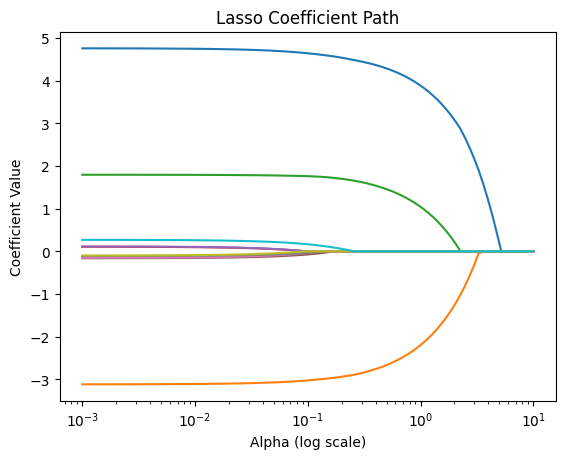

In [2]:
''' 
Create a Sparse Dataset
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV

np.random.seed(42)

n = 200
p = 10

X = np.random.randn(n, p)

# True coefficients (sparse)
true_beta = np.array([5, -3, 2, 0, 0, 0, 0, 0, 0, 0])

y = X @ true_beta + np.random.randn(n) * 2

'''
Onlt first 3 features matter. Others are noise.
'''

'''
Train-Test Split + Standardization
'''

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

'''
Compare OLS vs Lasso
'''

# OLS
ols = LinearRegression()
ols.fit(X_train, y_train)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# Predictions
ols_pred = ols.predict(X_test)
lasso_pred = lasso.predict(X_test)

print("OLS MSE:", mean_squared_error(y_test, ols_pred))
print("Lasso MSE:", mean_squared_error(y_test, lasso_pred))

print("\nOLS Coefficients:", ols.coef_)
print("Lasso Coefficients:", lasso.coef_)

'''
Observations:
- OLS assigns small weights to all features
- Lasso sets many coefficients exactly to 0
- Sparse solution recovered
'''

'''
Lasso with Cross-Validation
'''

alphas = np.logspace(-3, 1, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=5000)
lasso_cv.fit(X_train, y_train)

print("Best Alpha:", lasso_cv.alpha_)
print("Selected Coefficients:", lasso_cv.coef_)

'''
Lasso Coefficient Path Visualization
'''
alphas = np.logspace(-3, 1, 100)
coefs = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=5000)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(X.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Coefficient Path")
plt.show()

### ElasticNet (Combination)
$
J(w) = MSE + \lambda_1 \sum |w_i| + \lambda_2 \sum w_i^2
$

Combines:
- Ridge stability
- Lasso sparsity

#### Python Example


OLS
MSE: 3.5861885648430087
Coefficients: [ 5.09945775  3.60397257 -3.33566329 -2.1332836   2.07819522 -0.10768709
  0.07311891 -0.07696053 -0.12113311 -0.30773278 -0.0972336   0.00703888]

Ridge
MSE: 3.598066324709598
Coefficients: [ 4.77951552e+00  3.90806923e+00 -3.19713871e+00 -2.25828158e+00
  2.06598663e+00 -1.08293823e-01  7.22510046e-02 -8.11856927e-02
 -1.12830575e-01 -3.04176833e-01 -1.04499960e-01 -4.38172493e-04]

Lasso
MSE: 3.6578199449839617
Coefficients: [ 5.07211478e+00  3.56043693e+00 -3.22460343e+00 -2.11945228e+00
  1.97834490e+00 -3.66872491e-03  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -1.86538645e-01 -6.04591150e-04 -0.00000000e+00]

ElasticNet
MSE: 3.833896536795308
Coefficients: [ 4.30948739  4.15884365 -2.78420412 -2.49100564  1.90771491 -0.04857761
  0.02993938 -0.02910238 -0.028049   -0.24423242 -0.08714196 -0.        ]
Best Alpha: 0.10985411419875583
Best l1_ratio: 0.9
Selected Coefficients: [ 4.56234638  4.02728864 -2.98965498 -2.32624036  1.9516456

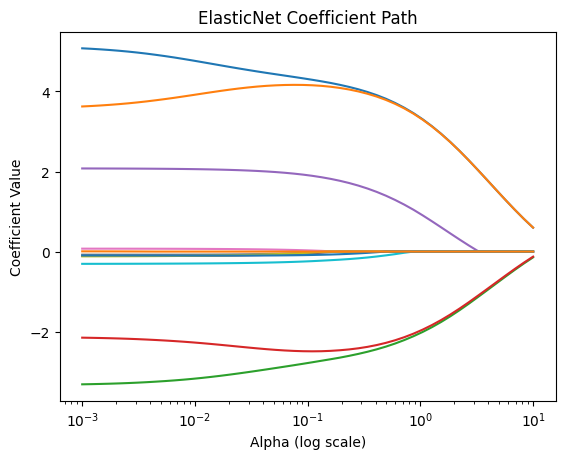

In [3]:
'''
Create Dataset (Correlated + Sparse)
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

n = 300
p = 12

X = np.random.randn(n, p)

# Create correlated features
X[:, 1] = X[:, 0] * 0.9 + np.random.randn(n) * 0.1
X[:, 3] = X[:, 2] * 0.85 + np.random.randn(n) * 0.15

# Sparse true coefficients
true_beta = np.array([5, 5, -3, -3, 2, 0, 0, 0, 0, 0, 0, 0])

y = X @ true_beta + np.random.randn(n) * 2

'''
- Correlated pairs (0, 1) and (2, 3)
- Some irrelevant features
'''

'''
Train-Test Split + Scaling
'''

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

'''
Compare Models
'''

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_test, preds))
    print("Coefficients:", model.coef_)

'''
Observations:
- OLS - unstable due to correlation
- Ridge - keeps correlated features
- Lasso - may drop one of correlated pair
- ElasticNet - keeps grouped correlated features but still sparse
'''

'''
ElasticNet with Corss-Validation
'''

from sklearn.linear_model import ElasticNetCV

elastic_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    alphas=np.logspace(-3, 1, 50),
    cv=5,
    max_iter=5000
)

elastic_cv.fit(X_train, y_train)

print("Best Alpha:", elastic_cv.alpha_)
print("Best l1_ratio:", elastic_cv.l1_ratio_)
print("Selected Coefficients:", elastic_cv.coef_)

'''
This automatically selects:
- Optimal regularization strength
- Optimal L1/L2 balance
'''

'''
Coefficient Path Visualization
'''

alphas = np.logspace(-3, 1, 50)
coefs = []

for alpha in alphas:
    model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)

coefs = np.array(coefs)

plt.figure()
for i in range(X.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("ElasticNet Coefficient Path")
plt.show()


- `l1_ratio=0` -> Ridge
- `l1_ratio=1` -> Lasso

### Geometric Intuition
L2 (Ridge):
- Circular constraint
- Shrinks weights smoothly

L1 (Lasso):
- Diamond constraint
- Corners force weights to zero

That’s why Lasso selects features.

### When to Use What?
| Scenario                 | Use        |
| ------------------------ | ---------- |
| Multicollinearity        | Ridge      |
| Feature selection needed | Lasso      |
| Many correlated features | ElasticNet |
| Small dataset            | Ridge      |


### Effect of Lambda
If λ = 0:
- Normal Linear Regression

If λ very large:
- Weights shrink toward zero
- Underfitting